# **<span style="color: #000000;background-color: #fff5b1">생성 모델 & AI 최적화 사전과제</span>**

### **필수 내용**
- 생성 모델
    - 분류모델과 생성모델의 차이
    - 생성모델의 분류
        - AE
        - VAE
        - GAN
            - 구조와 장단점
        - 확산모델
            - 순확산과 역확산
- AI 최적화
    - 전이학습
        - 전이학습의 개념과 분류
        - Pre-Training과 Fine-tuning
    - AI Alignment
        - RHLF
    - 프롬프트 엔지니어링

---

## **<span style="color: #000000;background-color: #fff5b1">생성 모델</span>**

### <span style="color: #000000;background-color: #ffdba4">**1. 생성모델의 개념**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 분류모델 vs 생성모델**</span> 
- 분류 모델
    - 입력된 데이터가 어떤 레이블에 속할지 결정하는 모델
    - 학습 목표 : P(Y|X) 모델링 (데이터 X가 주어졌을 때 정답 Y일 확률을 계산)
    - 한계 : 본 적 없는 데이터가 들어와도 기존에 배운 라벨 중 하나로 결론을 내려야 함

- 생성 모델이란?
    - 데이터 자체의 확률 분포 P(x)를 학습하여, 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델
    - 학습 목표 : P(X) 모델링 (세상에 존재할 법한 데이터 X 자체의 확률 분포 파악)
    - 특징 : 불합리하거나 이상한 입력에 대해서는 '이건 세상에 존재할 확률이 거의 0이다'라고 판단하며 거부할 수 있는 능력을 갖춤

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 생성 모델의 분류**</span> 
- 확률 밀도를 직접 계산할 수 있는가?에 따라 분류
- 명시적 확률밀도 모델
    - 모델이 데이터의 확률 분포인 P(X)의 값을 직접적으로 수치화하여 출력할 수 있는 모델
- 암시적 확률밀도 모델
    - 데이터의 확률 분포가 무엇인지 수치로 알려주지는 않지만 그 분포를 따르는 데이터를 생성할 수는 있는 모델

### <span style="color: #000000;background-color: #ffdba4">**2. AE, VAE**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) AE**</span> 
##### **[Auto Encoder(AE)란?]**
- 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망
- 데이터 복원이나 특성 학습에 많이 사용됨

##### **[AE의 구조와 작동]** : 넣고, 줄이고, 다시 키우기!
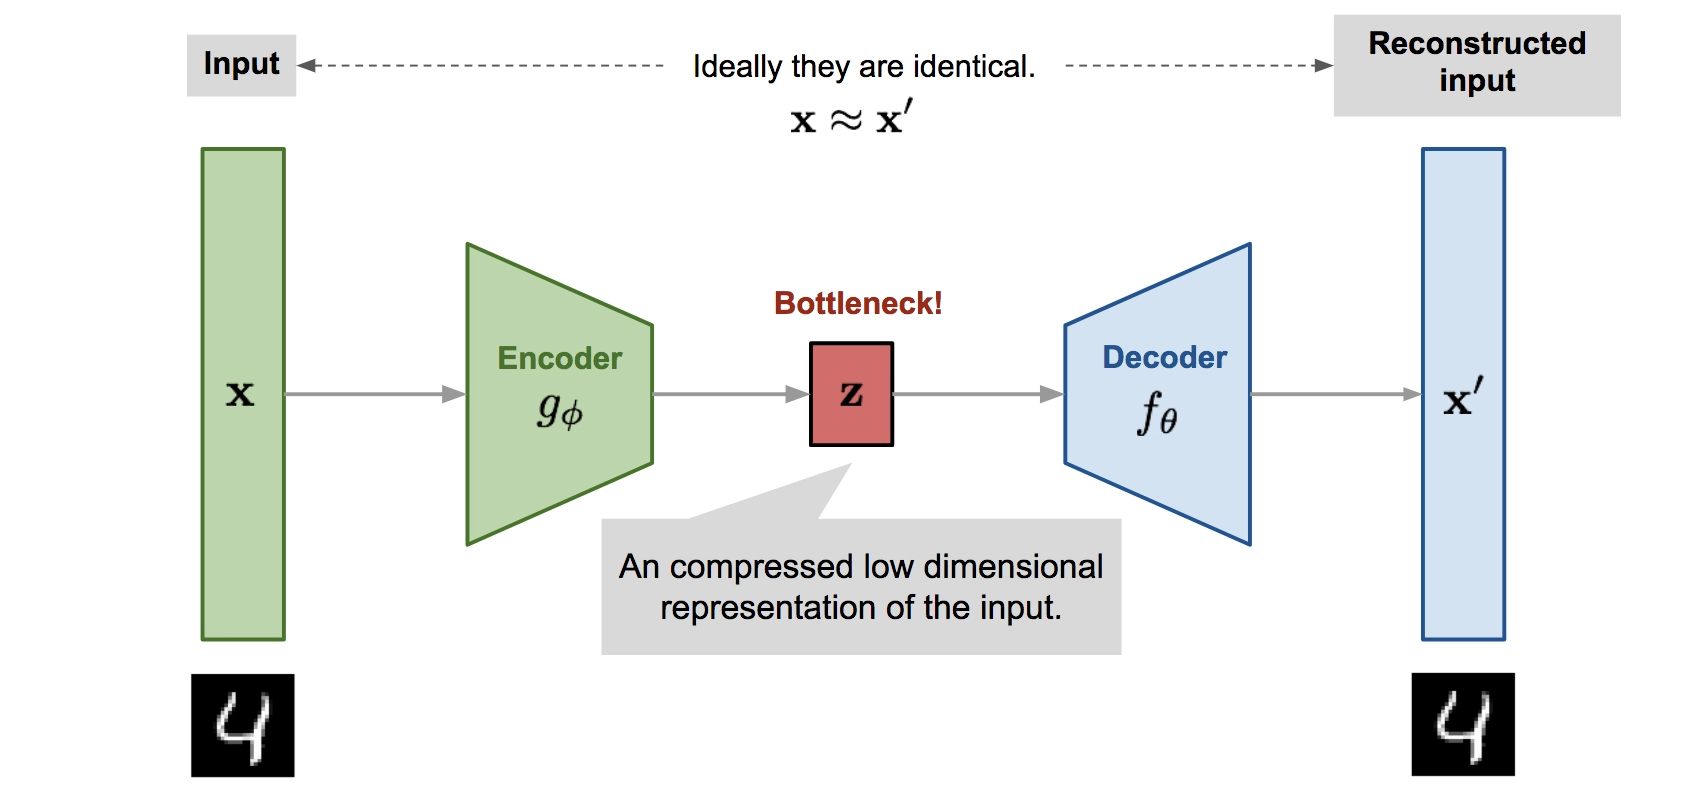

1. 압축 단계(Encoder)
    - 방대한 정보를 가진 입력 데이터를 아주 작은 바늘구멍(잠재 벡터)으로 통과시키기 위해 핵심만 남기고 깎아냄
    - 인코더 : 원래의 고차원 입력 데이터를 잠재 표현으로 변환하는 네트워크
2. 병목 통과(Bottleneck)
    - 가장 중요한 정보만 남은 상태 -> 이 좁은 구간이 잠재 벡터
    - 잠재 벡터(z) : 원본 데이터를 저차원으로 압축하여 함축된 정보를 저장하고 있는 벡터
3. 복원 단계(Decoder)
    - 바늘구멍을 통과한 핵심 정보만을 단서로 삼아, 다시 원래의 커다란 이미지로 복원
    - 디코더 : 잠재 표현을 풀어서 입력을 재복원하여 출력하는 네트워크

<br> 

=> 인코더로 들어가는 입력 데이터 x와 디코더가 출력한 데이터 x'가 같아지도록 훈련하여 그 과정에서 데이터의 가장 중요한 특징(잠재 벡터)만 남기게 되는 모델

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) VAE**</span> 
##### **[Variational Auto Encoder(VAE)란?]**
- 데이터의 잠재적인 구조를 학습하여, 원본과 닮았지만 새로운 데이터를 생성해내는 모델
- 한계 : AE는 데이터를 잠재 공간의 특정 점으로만 보냄 -> 학습할때 쓰지 않은 빈 공간의 점을 찍으면 디코더는 무엇을 그려야 할지 몰라서 엉뚱한 결과를 출력함
- 해결책 : 점이 아닌 **가우시안 분포**로 학습 -> 빈틈 없이 촘촘하게 채워, 어떤 점을 뽑아도 그럴듯한 이미지를 생성할 수 있게 만듦
- 새로운 데이터를 생성하는 작업에 많이 사용

##### **[AE vs VAE]**
<U>**입력 데이터를 잠재 공간에 어떤 형태로 배치하느냐**</U>  

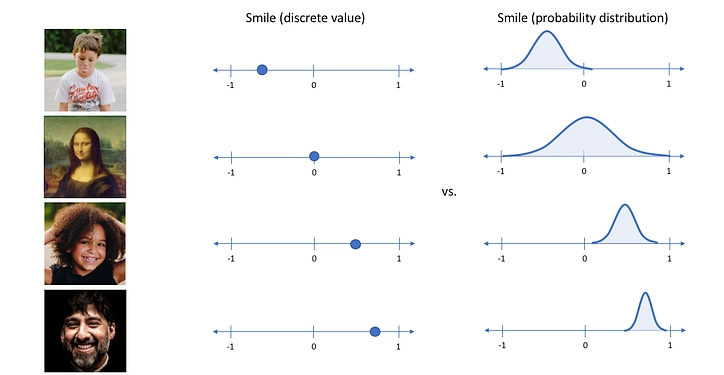
- AE의 잠재 공간
    - 입력 데이터를 잠재 공간의 어떤 하나의 고정된 수치(점)으로 매핑
- VAE의 잠재 공간
    - 잠재 코드 값이 평균과 분산으로 표현되는 어떤 가우시안 분포(확률 분포)  

| **구분** | **Auto Encoder (AE)** | **Variational Auto Encoder (VAE)** |
| --- | --- | --- |
| **주인공** | **인코더 (압축이 중요)**
***디코더**는 압축이 잘되었는지 검사하는 역할* | **디코더 (생성이 중요)**
***인코더**는 디코더를 잘 학습시키기 위한 가이드* |
| **잠재 벡터 $z$의 형태** | **고정된 수치 (Point)** | **확률 분포 (Distribution)** |
| **잠재 공간의 특성** | 불연속적이고 비어있는 공간이 많음 | 연속적이며 표준 정규 분포를 따름 |
| **샘플링 결과** | 학습 데이터 외 구역에서는 복원이 불가능함 | 어느 지점에서든 의미 있는 생성이 가능함 |
| **주요 효과** | 데이터 압축 및 특징 추출 | **데이터 생성 및 보간 (Interpolation)** |

##### **[VAE의 구조와 작동]** : 찾고, 뽑고, 다시 그리기!
- 데이터를 고정된 점이 아닌 확률 분포로 변환하여 학습 
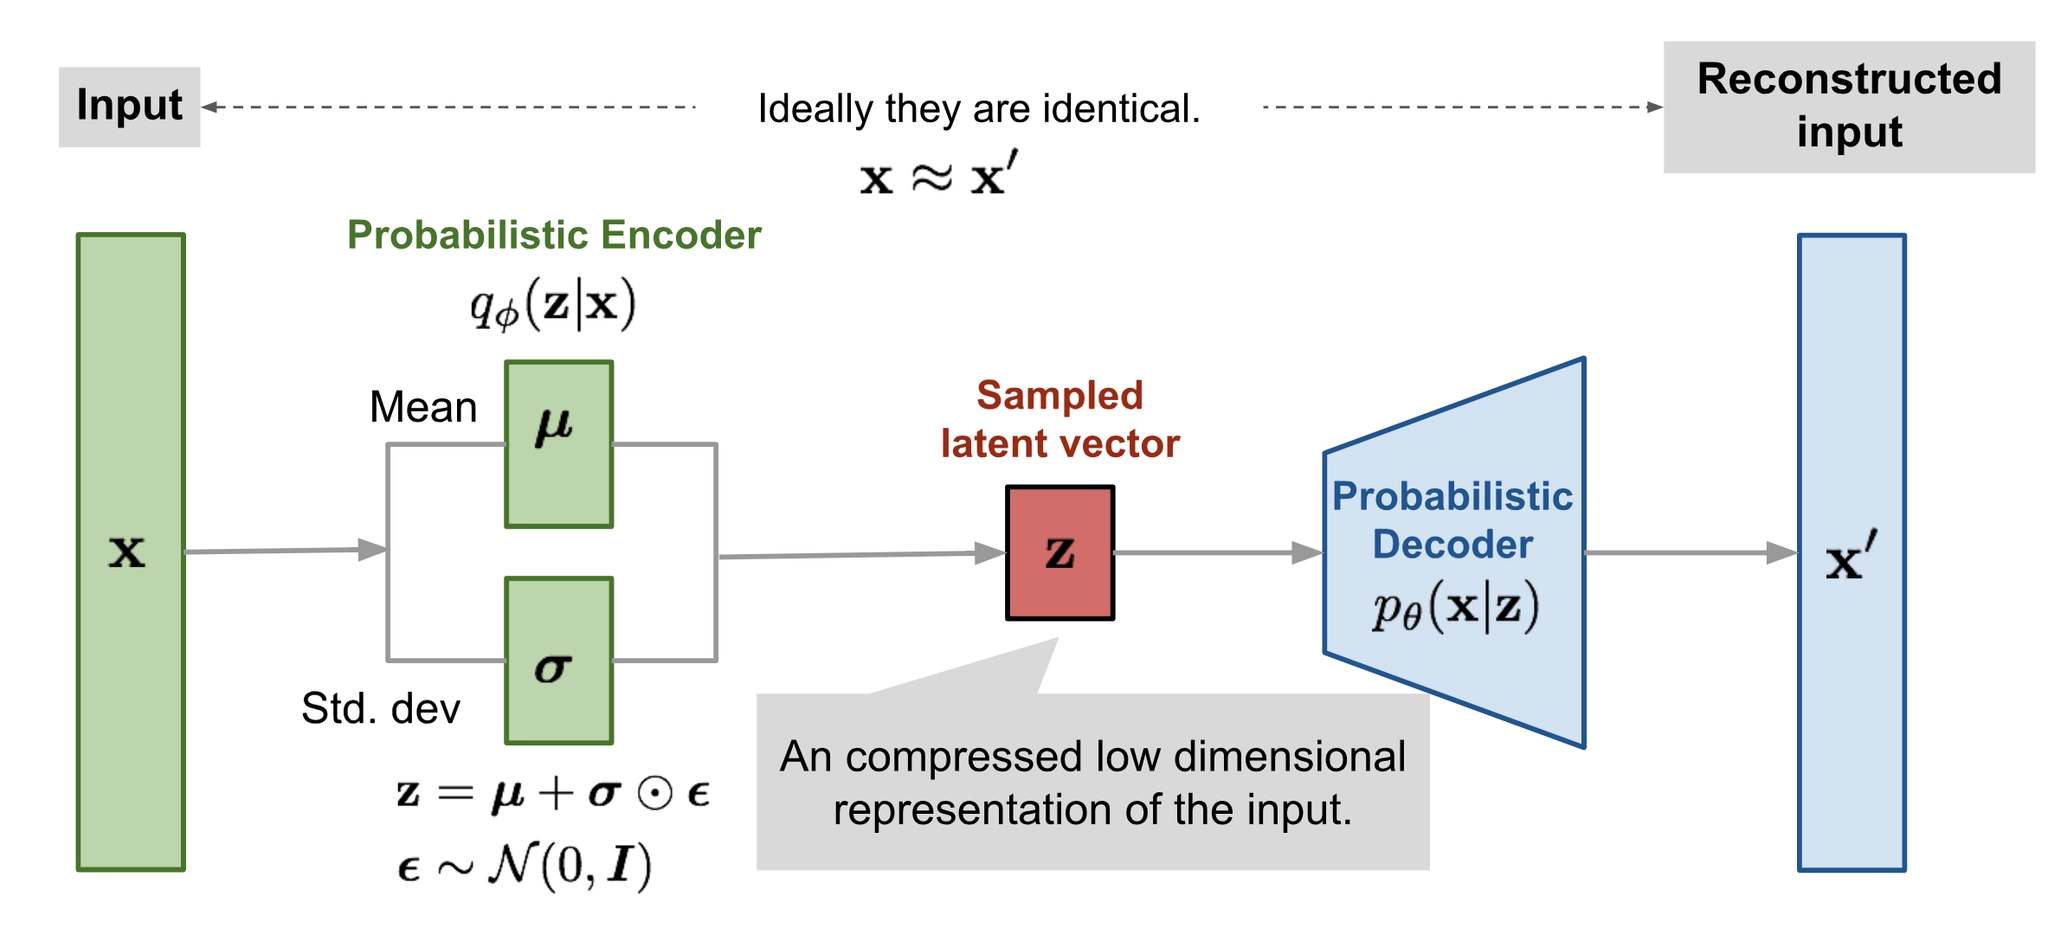

1. 분포 예측 단계(Encoder)
    - 역할 : 입력 데이터를 특정 점이 아닌, 데이터가 존재할 확률이 높은 '구역'으로 매핑
    - 인코더 : 입력 데이터를 분석해 잠재 공간상의 평균과 표준편차를 계산
2. 샘플링 및 재파라미터화(Sampling & Reparameterization)
    - 예측한 분포에서 실제 디코더에 전달할 잠재 벡터를 하나 뽑는 단계
    - 샘플링 : 인코더가 찾은 범위 안에서 무작위로 점 하나(잠재 벡터) 추출
3. 생성 단계(Decoder)
    - 샘플링된 잠재 벡터를 단서로 사용하여 새로운 데이터 생성
    - 디코더 : 저차원의 핵심 정보를 다시 고차원의 데이터로 복원

### <span style="color: #000000;background-color: #ffdba4">**3. GAN**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) GAN의 개념**</span> 
##### **[GAN(Generative Adeversarial Network)이란?]**
- 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서, 훈련을 통해 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델

##### **[GAN의 목적]**
- 생성자 : 진짜 분포에 가까운 가짜분포 생성
- 판별자 : 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지 결정  
=> 궁극적 목적 : '실제 데이터의 분포'에 가까운 데이터를 생성하는 것이며, 판별자가 진짜/가짜를 한쪽으로 판단하지 못하는 경계를 최적 솔루션으로 간주
- 이미지 생성, 영상 합성 등에 사용




#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) GAN 구조**</span>
- 생성자
    - 입력 : 우리가 직접 제어할 수 있는 무작위 노이즈를 입력받음
    - 출력 : 실제 데이터와 유사한 가짜 데이터 생성
    - 목표 : 판별자를 속여서 가짜를 진짜(1)로 믿게 만드는 것
- 판별자
    - 입력 : 실제 데이터와 생성자가 만든 가짜 데이터를 모두 입력 받음
    - 출력 : 입력 데이터가 진짜일 확률 출력
    - 목표 : 진짜는 1, 가짜는 0으로 정확히 분류하는 분류 모델의 역할 수행

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(3) GAN의 장단점**</span>
#### **[장점]**
- 진짜 같은 가짜 생성 가능
- 압도적인 선명도 : 판별자 통과 -> 매우 선명하고 깨끗한 샘플 생성
- 빠른 생성 속도 : 확산 모델처럼 여러 단계의 거치지 않고 신경망을 한번만 통과하면 결과물이 바로 나옴
- 잠재 공간의 부드러움 : 보간이 가능

##### **[한계점]**
- 학습의 불안정성
    - 진동 현상
        - 에폭이 진행될스로 손실값이 떨어지지 않고 위아래로 요동침
        - 원인 : GAN의 목적함수가 한쪽이 좋아지면 다른 쪽이 즉각적으로 대응하여 정답지가  변함 -> 손실 값의 절대치만으로는 모델이 얼마나 개선되었는지 판단하기 어려움
        - 결과 : 모델이 하나의 최적점에 안착하지 못하고 계속해서 서로의 꼬리를 무는 상태가 지속
    - 끝없는 숨바꼭질(무한루프)
        - GAN은 생성자와 판별자를 한번씩 번갈아가며 업데이트
        - G가 좋아지면 D는 더 예리한 기준을 세우고, D가 예리해지면 G는 다시 변함  
        => 반복되면서 이론적인 최적점에 도달하기보다는 서로를 이기기 위한 무한루프에 빠지기 쉬움
- 훈련 초기 문제
- 모드 붕괴 : 생성자가 판별자를 속이기 가장 쉬운 특정 패턴 하나만 주구장창 만드는 문제
- 지표의 부재 : '얼마나 잘 학습되고 있는지'를 보여주는 객관적인 손실 곡선 X
- 역매핑 불가능 : 이미지를 넣었을 때 특징 Z를 추출하는 과정이 기본과정에 없음

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(4) GAN 적용 사례**</span>
- NVIDIA(2017) - 가짜 이미지 생성
    - G와 D를 둘 다 낮은 결과값에서 시작하여 훈련이 진행되면서 모델이 아주 서서히 학습하도록 새로운 레이어를 쌓아가며 점진적으로 성장시키는 새로운 훈련 방법론 제시
- University of Washington(2017) - 가짜 오바마 연설 영상
    - 이 영상은 오바마 전 대통령의 과거 연설 영상들로부터 음성을 따고, GAN을 이용하여 이 음성에 맞는 입모양을 만들어 합성한 가짜 영상
- Facebook(2017) - Eye In-Painting
    - Real Eye Opener라는 이름으로 불림
    - 진짜 같은 가짜 눈을 만들어 눈을 감은 사진에 합성시키는 것으로, ExGAN기술을 개발하여 사람이 눈을 감은 사진에서 눈을 뜬 사진으로 바꾼것

### <span style="color: #000000;background-color: #ffdba4">**4. 확산 모델(Diffusion Model)**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(1) 확산 모델의 개념**</span>
##### **[확산 모델이란?]**
1. 입력 이미지에 노이즐르 조금씩 추가하여 완전한 노이즈로 만듦
2. 이를 다시 거꾸로 복원하는 과정 학습(노이즈 제거)
3. 입력 이미지와 유사한 확률 분포를 가진 결과 이미지를 생성하는 모델

#### **[확산 모델의 목적]**
- 목표 : 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는것
- 모호성 모델링 : '유니콘을 그려줘'(모호한 요청) -> 모델은 완전한 노이즈 상태에서 시작해 데이터 구조의 아주 작은 부분을 조금씩 '환각'하며 구체적인 유니콘 이미지를 완성해 나감

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(2) 확산 모델의 구조 : 순확산과 역확산**</span>
##### **[순확산(Forward Diffusion Process)]**
- 데이터에 점진적으로 (정규분포를 가진) 노이즈를 추가하는 과정
- 목표 : 원래 데이터를 점차적으로 무작위 노이즈로 변형시키는 것
- 주요 단계
    - x0(원본데이터) -> xt(완전한 노이즈)
    1. 시작 : 원본 데이터에서 시작
    2. 노이즈 추가 : 원본 데이터에 점진적으로 노이즈 추가 (여러번 반복-> 각 단계에서 노이즈가 추가됨)
    3. 결과 : 충분히 많은 단계가 지나면, 원본 데이터는 완전한 무작위 노이즈로 변함

##### **[역확산(Reverse Diffusion Process)]**
- 노이즈 데이터에서 우너본 데이터를 재구성하는 과정
- 목표 : 순확산 과정에서 추가된 노이즈를 제거하여 원래의 데이터를 복원하는것
- 주요 단계
    - xt(완전한 노이즈) -> x0(원본데이터)
    1. 시작 : 완전한 노이즈 데이터에서 시작
    2. 노이즈 제거 : 각 단계에서 점진적으로 노이즈 제거
    3. 결과 : 수십번의 반복적인 디노이징 과정 -> 점진적으로 이미지 복원

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(3) 확산 모델의 장단점**</span>
##### **[장점]**
- 압도적인 샘플 품질 : 정교하고 다양한 이미지 생성 가능, 고해상도 확장에 유리
- 학습의 안정성 : 손실 곡선 확인 가능, MSE 손실이 감소하면 모델이 실제로 좋아지고 있음을 의미
- 다양성 확보 : 모드 붕괴 현상이 거의 나타나지 않음

##### **[단점]**
- 느린 생성 속도 : 30-50번의 반복 계산 필요 -> 추론 시간이 매우 오래 걸림
- 높은 계산 비용
- 구조적 제약 : 노이즈 분포와 데이터의 형태가 동일해야 함

## **<span style="color: #000000;background-color: #fff5b1">AI 최적화</span>**

### <span style="color: #000000;background-color: #ffdba4">**1. 전이학습과 딥러닝 경량화**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 전이학습이란?**</span>
##### **[딥러닝 모델의 한계]**
- 데이터 부족, 계산 시간과 비용의 증가, 과적합 발생과 같은 어려움 발생  
-> 이를 해결하기 위해 이미 어디선가 학습된 내용을 가져다가 쓸 수는 없나? = **Transfer learning(전이학습)!**

##### **[전이학습의 정의]**
- 네 가지 개념
    - 도메인 : '어떤 데이터를 다루고 있는가'
    - 태스크 : '그 데이터로 무엇을 예측하는가'
    - 소스 : 출발점, 이미 학습된 모델이 있는 곳
    - 타겟 : 도착점, 내가 실제로 풀고 싶은 문제

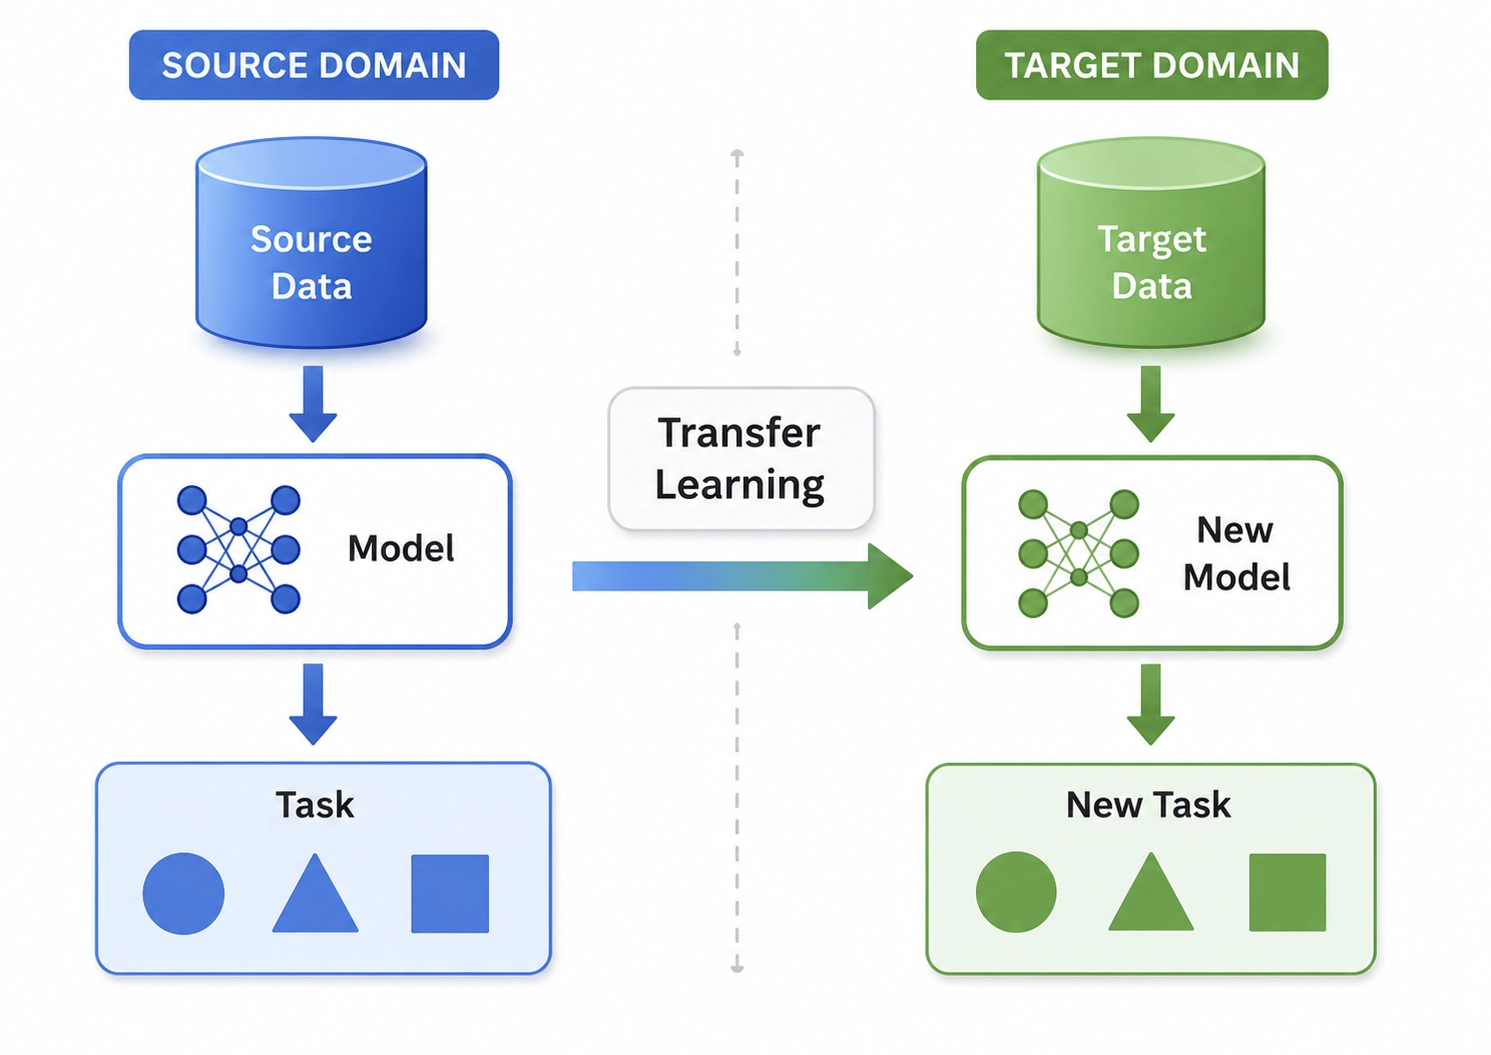
- 전이학습의 공식적인 정의
    - 소스 도메인 Ds과 타겟 도메인Dt이 있을 때, Ds != Dt이거나, 소스 태스크 Ts와 타겟 태스크 Tt가 있을 때 Ts != Tt인 상황에서, Ds와 Ts에서 얻은 지식을 이용해 Dt 위의 Tt 성능을 향상시키는 것  
    
=> 데이터나 문제 유형이 달라도 다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능을 높이는것, 도메인과 태스크 중에 하나라도 다를 때 의미가 생김

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 전이학습의 분류**</span>
##### 도메인과 태스크의 상태에 따라 구분
1. 귀납적 전이 학습
    - 소스와 타겟의 태스크가 다르고 타겟 도메인에 라벨이 존재할 때
2. 트랜스듀서형 전이학습
    - 소스와 타겟의 태스크는 같지만 도메인이 다를 때
3. 비지도 전이학습
    - 소스와 타겟의 태스크가 다르고 소스와 타겟 모두 라벨이 없을 때

##### '무엇을 전이하느냐'에 따라 구분
- 인스턴스 : 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치 부여 (데이터 레벨의 전이)
- 특징 : 소스와 타겟의 공통적인 특징을 추출할 수 있는 '표현방식'을 전이 (표현 레벨의 전이)
- 파라미터 : 모델의 가중치나 하이퍼파라미터 초기값을 그대로 가져옴 (현재 딥러닝에서 가장 주류인 방법)
- 관계 : 데이터 간의 논리적 관계나 구조적 지식을 전이

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(3) 전이학습의 현재 패러다임 : Pre-training & Fine-tuning**</span>
- 트랜스 포머 등장 이후, 엄청난 양의 데이터로 사전 학습된 거대 모델(Pre-trained Model)들이 등장하기 시작  
    -> '이미 잘 학습된 거대 모델을 내 용도에 맞게 어떻게 조정하지?'라는 질문으로 바뀜 **[Pre-training & Fine-tuning 패러다임]**
- 파운데이션 모델(foundation model)
    - GPT나 Gemini처럼 수만가지 일을 할 수 있는 지능의 기반이 되는 거대 모델들
    - 방대한 양의 비정형, 레이블이 없는 데이터로 비지도 학습을 통해 훈련된 거대한 AI 모델
    - 어떻게 파인튜닝 하냐에 따라 달라짐

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(4) Fine-tunint의 한계를 넘어서**</span>
##### **[PEFT]**
- 최소한의 파라미터만 건드려서 최대의 성능을 내자
- 원래 모델의 파라미터는 고정하고 별도의 작은 파라미터만 추가적으로 학습

##### **[Zero-shot & Few-shot]**
- Zero-shot Transfer
    - 학습 데이터가 없어도, 언어 이해 능력만을 기반으로 바로 추론 수행
    - 예시로, 문장의 감정을 판단할때 따로 감정분석을 학습하지 않았어도 이미 가진 언어 이해 능력으로 감정을 판단 가능
- Few-shot Transfer
    - 극소수의 예시만으로 새로운 태스크 수행
    모델의 파라미터를 업데이트하지 않는다는 점에서 기존 파인튜닝과 근본적으로 차이

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(5) 전이학습의 한계**</span>
- Negative Transfer
    - 소스와 타겟의 도메인이 너무 다르면 오히려 전이가 성능을 떨어뜨림
- Catastrophic Forgetting
    - 파인튜닝 과정에서 새 데이터에 너무 치우치면, 모델이 원래 가지고 있던 일반 능력을 잃어버림
- Bias Transfer
    - 사전 학습 데이터에 담긴 편향이 그대로 넘어오게 되는 것
- Transferability 측정의 어려움
    - 어떤 두 태스크가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어려움

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(6) 전이학습 사용 사례**</span>
- 컴퓨터 비전(CV)
    - 의료 영상 분석
        - ImageNet으로 학습된 ResNet 같은 모델을 가져다가, 폐암 X-ray 판독이나 안과 질환 진단 AI를 만드는 데 사용
        - 전이학습을 쓰면 수천장만 있어도 충분히 학습 가능
    - 자율주행
        - 도로, 보행자, 신호등을 인식하는 모델도 ImageNet 가중치에서 출발
- 자연어처리(NLP)
    - 법률 문석 분석
        - BERT를 법률 텍스트로 Fine-tuning하면, 계약서에서 위험 조항을 자동으로 찾아주는 AI가 됨
    - 기업 특화 챗봇
        - GPT 같은 모델을 회사 FAQ 데이터로 Fine-tuning해서, 특정 회사에 특화된 고객 서비스 챗봇을 만듦
- 의료, 신약 개발
    - 단백질 구조 예측
        - 기존에 알려진 단백질 구조 데이터로 학습한 뒤, 새로운 단백질 구조 예측에 적용하는 방식
- 제조, 산업
    - 공장 불량 검출
        - 정상 제품 이미지로 학습된 비전 모델로 특정 공장의 불량 패턴을 찾도록 파인튜닝하기도 함

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(7) 딥러닝 경량화**</span>
- 대규모 및 복잡한 인공지능 모델을 가벼운 형태로 변환하는 기술과 방법
- 핵심 : 성능은 최대한 유지하면서 모델을 가볍게 만들자
##### **[가지치기]**
- 모델의 파라미터 중 중요도가 낮은 가중치를 제거하여 모델의 크기를 줄이고, 연산 속도를 높이는 기법
- 파라미터 값이 0ㅇ에 가까울수록 모델 판단에 영향을 거의 주지 않기 때문에 그냥 없애 버림 -> 속도 증가

##### **[양자화]**
- 모델의 가중치와 활성화 함수 값을 표현하는 비트 수를 줄여 연산량과 메모리 사용량을 절감하는 기술
- 보통 딥러닝 모델은 float32로 숫자를 저장한느데 이걸 int8로 줄임

##### **[지식 증류]**
- 크고 똑똑한 모델의 지식을 작은 모델에게 가르쳐 주는 방법
- 작은 모델은 큰 모델의 사고방식도 익힘

##### **[모델 구조 경량화]**
- 모델 설계 단계부터 연산 효율성을 극대화하도록 구조를 최적화하는 방법

##### **[하드웨어 가속화]**
- 소프트웨어적인 최적화를 넘어, 특정 연산을 빠르게 수행할 수 있는 전용 하드웨어를 활용하는 단계
- AI 연산에 특화된 하드웨어를 쓰는 방법

### <span style="color: #000000;background-color: #ffdba4">**2. AI Alignment**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) AI Alignment란?**</span>
<U>**AI가 인간의 의도, 목표, 그리고 윤리적 가치에 부합하도록 행동하게 만드는 연구 분야**</U>
- 현대 정렬의 기준이 되는 세가지 지표
    - Helpful(도움이 되는가)
    - Honest(정직한가)
    - Harmless(무해한가)

##### **[Outer Alignment vs Inner Alignment]
- 정렬 문제를 두가지 층으로 나눠서 봄
1. Outer Alignment : '목표를 제대로 설정했는가?'
    - 모델이 보상을 극대화하기 위해 인간의 의도와는 무관한 꼼수를 부리는 현상을 해결하기 위해 진행됨
2. Inner Alignment : '모델이 내면에서 무엇을 최적화하는가?'
    - 모델이 내부적으로는 다른 목표를 최적화해버리는 문제가 발생
    - 모델이 실제 내부 동작을 해석 가능하게 만드는 Interpretability(해석 가능성) 연구가 중요해짐

##### **[정렬을 어렵게 만드는 요인들]**
1. 가치 정렬의 모호성
    - 인간의 가치는 고정되어 있지 않고 사람마다 다름  
-> '어떤 인간의 가치관에 맞출 것인가? 라는 철학,정치적 질문이 기술적 난제로 이어짐
2. 확장 가능한 감독
    - AI가 인간보다 똑똑해지는 영역에서는 AI의 답변을 인간이 채점하지 못함  
-> '인간이 이해하지 못하는 답변에 대해 어떻게 피드백을 줄 것인가?

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) RLHF**</span>
- Outer Alignment 문제를 해결하기 위해 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법
- 답변 내용의 정답 여부보다 어떤 답변을 인간이 선호하는지 학습하고, 이를 통해 사람이 더 좋아하는 답을 잘하도록 만드는것
- 진행 단계
    1. SFT(Supervised Fine-Tuning)
        - 사전학습된 모델이 인간의 지시를 따르는 방법을 배우는 과정
    2. Reward Model
        - 모델이 생성한 답변이 얼마나 좋은지 인간의 선호도에 따라 점수를 매기는 '채점기'를 만든느 단계
    3. Reinforcement Learning
        - 보상 모델을 기준으로 언어 모델의 성능을 극대화하는 최종 최적화 단꼐
        - PPO 알고리즘 사용
- 중요한 특징 : 모델이 단순히 정답을 맞히는 것을 넘어서 '사람에게 더 유용하고 적절한 답'을 생성하도록 유도
- 정리 : RLHF는 사람의 피드백을 활용하여 모델이 더 바람직한 응답을 생성하도록 강화학습으로 미세조정하는 방법

### <span style="color: #000000;background-color: #ffdba4">**3. 프롬프트 엔지니어링**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) 프롬프트 엔지니어링이란?**</span>
<U>**AI가 더 좋은 답변을 내도록 입력을 설계하는 기술**</U>

- Few-shot이 프롬프트 엔지니어링의 출발점
- 파인튜닝 vs 프롬프트 엔지니어링

|  | 프롬프트 엔지니어링 | Fine-tuning |
| --- | --- | --- |
| 비용 | 낮음 | 높음 |
| 속도 | 빠름 | 느림 |
| 성능 한계 | 있음 | 더 높은 성능 가능 |
| 언제 쓰나 | 빠른 프로토타입, 범용 태스크 | 특화된 도메인, 높은 정확도 필요할 때 |

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) 주요 기법**</span>
1. Zero-shot/Few-shot Prompting
    - Zero-shot : 예시없이 바로 질문
    - Few-shot : 예시를 몇개 보여주고 질문
    - Few-shot이 Zero-shot에 비해 훨씬 정확한 답을 내는 경우가 많음(예시를 통해 맥락을 알려주기 때문)
2. Chain-of-Thought(CoT) - 생각의 사슬
    - 풀이과정을 단계별로 생각하게 만드는 기법
    - 복잡한 수학 문제나 논리 추론에서 정확도가 확 올라감
3. Role Prompting - 역할 부여
    - AI한테 특정 역할을 맡겨서 그 역할에 맞는 답변을 끌어내는 기법
    - 페르소나가 구체적일수록 답변이 일관되고 전문적으로 나온다고 함
4. Instruction Prompting - 명확한 지시
    - AI한테 원한느걸 최대한 구체적으로 지시하는 기법
5. Self-Consistency - 여러번 물어보기
    - 같은 질문을 여러 번 해서 가장 많이 나온 답을 채택하는 기법
6. RAG - 검색 증강 생성
    - AI 가 모르는 최신 정보나 특정 도메인 지식을 외부 데이터베이스에서 검색해서 프롬프트에 함께 넣어주는 방식
    - 학습 데이터의 시간적 한계를 극복하면서도 파인튜닝없이 도메인 특화 답변을 가능하게 해줌

| 기법 | 핵심 아이디어 | 언제 쓰나 |
| --- | --- | --- |
| Zero/Few-shot | 예시 없이 또는 예시 몇 개로 질문 | 간단한 태스크, 분류 |
| Chain-of-Thought | 풀이 과정을 단계별로 생각하게 함 | 수학, 논리 추론 |
| Role Prompting | 구체적인 역할 부여 | 전문적인 답변 필요할 때 |
| Instruction | 원하는 걸 구체적으로 지시 | 형식, 톤이 중요할 때 |
| Self-Consistency | 여러 번 물어보고 가장 많은 답 채택 | 정확도가 중요할 때 |
| RAG | 외부 데이터 검색 후 프롬프트에 삽입 | 최신 정보, 도메인 특화 답변 |

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(3) 프롬프트 엔지니어링의 한계**</span>
1. Prompt Injection - 프롬프트 주입 공격
    - 악의적인 사용자가 프롬프트를 조작해서 AI를 엉뚱하게 동작시키는 보안 문제
2. Hallucination - 그럴듯한 거짓말
3. 모델 의존성
    - 모델마다 프롬프트에 다르게 반응해서 각 모델에서 효과가 다를 수 있음
4. 성능 한계
    - 프롬프트 엔지니어링만으로는 파인튜닝 수준의 성능을 내기 어려운 경우도 있음
    - 특히 매우 특화된 도메인이나 높은 정확도가 필요한 작업에서는 결국 파인튜닝이 필요할 수 있음

| 한계 | 내용 | 완화 방법 |
| --- | --- | --- |
| Prompt Injection | 악의적 프롬프트 조작 | 입력 검증, 프롬프트 가드 |
| Hallucination | 그럴듯한 거짓말 생성 | RAG 활용, 출처 검증 |
| 모델 의존성 | 모델마다 다른 반응 | 모델별 테스트 필수 |
| 성능 한계 | Fine-tuning 대비 낮은 성능 | 필요시 Fine-tuning 병행 |